In [1]:
import requests

url = "https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html"

response = requests.get(url)

print(response.status_code)

200


In [2]:
from bs4 import BeautifulSoup

title= BeautifulSoup(response.text, "html.parser")

print(title.h1.text)

A Light in the Attic


In [3]:
response.encoding = "utf-8"

soup = BeautifulSoup(response.text, "html.parser")

price = soup.find("p", class_="price_color")

print(price.text)

£51.77


In [4]:
availability_text = soup.find("p", class_="instock availability")

print(availability_text.text.strip())

In stock (22 available)


In [5]:
rating = soup.find("p", class_="star-rating")

print(rating)

<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<!-- <small><a href="/catalogue/a-light-in-the-attic_1000/reviews/">
        
                
                    0 customer reviews
                
        </a></small>
         --> 


<!-- 
    <a id="write_review" href="/catalogue/a-light-in-the-attic_1000/reviews/add/#addreview" class="btn btn-success btn-sm">
        Write a review
    </a>

 --></p>


In [6]:
rating = soup.find("p", class_="star-rating")

rating_value = rating.get("class")[1]

print(rating_value)

Three


In [7]:
category = soup.find("ul", class_="breadcrumb").find_all("li")[2].get_text(strip=True)

print(category)

Poetry


In [8]:
upc = soup.find("th", string="UPC").find_next_sibling("td").get_text(strip=True)

print(upc)

a897fe39b1053632


In [9]:
reviews = soup.find("table", class_="table-striped").find_all("tr")[6].find("td").get_text(strip=True)

print(reviews)

0


In [10]:
book = {
    "title": title.h1.text.strip(),
    "price": price.text.strip(),
    "rating": rating_value,
    "availability": availability_text.text.strip(),
    "category": category,
    "upc": upc,
    "reviews": reviews
}

print(book)

{'title': 'A Light in the Attic', 'price': '£51.77', 'rating': 'Three', 'availability': 'In stock (22 available)', 'category': 'Poetry', 'upc': 'a897fe39b1053632', 'reviews': '0'}


In [11]:
books = []

books.append(book)

print(books)

[{'title': 'A Light in the Attic', 'price': '£51.77', 'rating': 'Three', 'availability': 'In stock (22 available)', 'category': 'Poetry', 'upc': 'a897fe39b1053632', 'reviews': '0'}]


In [12]:
base_url = "https://books.toscrape.com/catalogue/page-{}.html"

for page in range(1, 6):
    url = base_url.format(page)
    print(url)

https://books.toscrape.com/catalogue/page-1.html
https://books.toscrape.com/catalogue/page-2.html
https://books.toscrape.com/catalogue/page-3.html
https://books.toscrape.com/catalogue/page-4.html
https://books.toscrape.com/catalogue/page-5.html


In [13]:
url = "https://books.toscrape.com/catalogue/page-1.html"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

links = soup.find_all("h3")

print(len(links))

20


In [14]:
book_links = []

for h3 in links:
    a_tag = h3.find("a")
    book_links.append(a_tag.get("href"))

print(book_links)

['a-light-in-the-attic_1000/index.html', 'tipping-the-velvet_999/index.html', 'soumission_998/index.html', 'sharp-objects_997/index.html', 'sapiens-a-brief-history-of-humankind_996/index.html', 'the-requiem-red_995/index.html', 'the-dirty-little-secrets-of-getting-your-dream-job_994/index.html', 'the-coming-woman-a-novel-based-on-the-life-of-the-infamous-feminist-victoria-woodhull_993/index.html', 'the-boys-in-the-boat-nine-americans-and-their-epic-quest-for-gold-at-the-1936-berlin-olympics_992/index.html', 'the-black-maria_991/index.html', 'starving-hearts-triangular-trade-trilogy-1_990/index.html', 'shakespeares-sonnets_989/index.html', 'set-me-free_988/index.html', 'scott-pilgrims-precious-little-life-scott-pilgrim-1_987/index.html', 'rip-it-up-and-start-again_986/index.html', 'our-band-could-be-your-life-scenes-from-the-american-indie-underground-1981-1991_985/index.html', 'olio_984/index.html', 'mesaerion-the-best-science-fiction-stories-1800-1849_983/index.html', 'libertarianism-

In [15]:
base_url = "https://books.toscrape.com/catalogue/"

full_links = []

for link in book_links:
    full_links.append(base_url + link)

print(full_links)

['https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html', 'https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html', 'https://books.toscrape.com/catalogue/soumission_998/index.html', 'https://books.toscrape.com/catalogue/sharp-objects_997/index.html', 'https://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html', 'https://books.toscrape.com/catalogue/the-requiem-red_995/index.html', 'https://books.toscrape.com/catalogue/the-dirty-little-secrets-of-getting-your-dream-job_994/index.html', 'https://books.toscrape.com/catalogue/the-coming-woman-a-novel-based-on-the-life-of-the-infamous-feminist-victoria-woodhull_993/index.html', 'https://books.toscrape.com/catalogue/the-boys-in-the-boat-nine-americans-and-their-epic-quest-for-gold-at-the-1936-berlin-olympics_992/index.html', 'https://books.toscrape.com/catalogue/the-black-maria_991/index.html', 'https://books.toscrape.com/catalogue/starving-hearts-triangular-trade-trilogy-1_99

In [16]:
url = full_links[0]

response = requests.get(url)
response.encoding = "utf-8"

soup = BeautifulSoup(response.text, "html.parser")

title = soup.h1.text.strip()

price = soup.find("p", class_="price_color").text.strip()

availability_text = soup.find("p", class_="instock availability").text.strip()

rating = soup.find("p", class_="star-rating")
rating_value = rating.get("class")[1]

category = soup.find("ul", class_="breadcrumb").find_all("li")[2].get_text(strip=True)

upc = soup.find("th", string="UPC").find_next_sibling("td").get_text(strip=True)

reviews = soup.find("th", string="Number of reviews").find_next_sibling("td").get_text(strip=True)

book = {
    "title": title,
    "price": price,
    "rating": rating_value,
    "availability": availability_text,
    "category": category,
    "upc": upc,
    "reviews": reviews
}

print(book)
print(len(full_links))

{'title': 'A Light in the Attic', 'price': '£51.77', 'rating': 'Three', 'availability': 'In stock (22 available)', 'category': 'Poetry', 'upc': 'a897fe39b1053632', 'reviews': '0'}
20


In [38]:
books = []

In [39]:
for url in full_links:
    response = requests.get(url)
    response.encoding = "utf-8"

    soup = BeautifulSoup(response.text, "html.parser")

    title = soup.h1.text.strip()

    price = soup.find("p", class_="price_color").text.strip()

    availability_text = soup.find("p", class_="instock availability").text.strip()

    rating = soup.find("p", class_="star-rating")
    rating_value = rating.get("class")[1]

    category = soup.find("ul", class_="breadcrumb").find_all("li")[2].get_text(strip=True)

    upc = soup.find("th", string="UPC").find_next_sibling("td").get_text(strip=True)

    reviews = soup.find("th", string="Number of reviews").find_next_sibling("td").get_text(strip=True)

    book = {
        "title": title,
        "price": price,
        "rating": rating_value,
        "availability": availability_text,
        "category": category,
        "upc": upc,
        "reviews": reviews
    }

    books.append(book)

print(len(books))

20


In [19]:
print(books[0])
print(books[1])
print(books[2])

{'title': 'A Light in the Attic', 'price': '£51.77', 'rating': 'Three', 'availability': 'In stock (22 available)', 'category': 'Poetry', 'upc': 'a897fe39b1053632', 'reviews': '0'}
{'title': 'Tipping the Velvet', 'price': '£53.74', 'rating': 'One', 'availability': 'In stock (20 available)', 'category': 'Historical Fiction', 'upc': '90fa61229261140a', 'reviews': '0'}
{'title': 'Soumission', 'price': '£50.10', 'rating': 'One', 'availability': 'In stock (20 available)', 'category': 'Fiction', 'upc': '6957f44c3847a760', 'reviews': '0'}


In [20]:
for book in books:
    print(book["title"])

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


In [21]:
import pandas as pd

In [22]:
df = pd.DataFrame(books)

df

,title,price,rating,availability,category,upc,reviews
0,A Light in the Attic,£51.77,Three,In stock (22 available),Poetry,a897fe39b1053632,0
1,Tipping the Velvet,£53.74,One,In stock (20 available),Historical Fiction,90fa61229261140a,0
2,Soumission,£50.10,One,In stock (20 available),Fiction,6957f44c3847a760,0
3,Sharp Objects,£47.82,Four,In stock (20 available),Mystery,e00eb4fd7b871a48,0
4,Sapiens: A Brief History of Humankind,£54.23,Five,In stock (20 available),History,4165285e1663650f,0
5,The Requiem Red,£22.65,One,In stock (19 available),Young Adult,f77dbf2323deb740,0
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,Four,In stock (19 available),Business,2597b5a345f45e1b,0
7,The Coming Woman: A Novel Based on the Life of...,£17.93,Three,In stock (19 available),Default,e72a5dfc7e9267b2,0
8,The Boys in the Boat: Nine Americans and Their...,£22.60,Four,In stock (19 available),Default,e10e1e165dc8be4a,0
9,The Black Maria,£52.15,One,In stock (19 available),Poetry,1dfe412b8ac00530,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         20 non-null     object
 1   price         20 non-null     object
 2   rating        20 non-null     object
 3   availability  20 non-null     object
 4   category      20 non-null     object
 5   upc           20 non-null     object
 6   reviews       20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


In [24]:
## access first five row
df.head()

,title,price,rating,availability,category,upc,reviews
0,A Light in the Attic,£51.77,Three,In stock (22 available),Poetry,a897fe39b1053632,0
1,Tipping the Velvet,£53.74,One,In stock (20 available),Historical Fiction,90fa61229261140a,0
2,Soumission,£50.10,One,In stock (20 available),Fiction,6957f44c3847a760,0
3,Sharp Objects,£47.82,Four,In stock (20 available),Mystery,e00eb4fd7b871a48,0
4,Sapiens: A Brief History of Humankind,£54.23,Five,In stock (20 available),History,4165285e1663650f,0


In [25]:
# Numerical/statistical summary check karna
df.describe()

,title,price,rating,availability,category,upc,reviews
count,20,20,20,20,20,20,20
unique,20,20,5,3,13,20,1
top,A Light in the Attic,£51.77,One,In stock (19 available),Poetry,a897fe39b1053632,0
freq,1,1,6,15,4,1,20


In [26]:
# Price column se £ symbol remove karna
df["price"] = df["price"].str.replace("£", "", regex=False)

# Price ko string se numeric (float) mein convert karna
df["price"] = df["price"].astype(float)

# Check karna ki price successfully convert hua ya nahi
print(df["price"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: price, dtype: float64


In [27]:
# Rating words ko numbers mein convert karne ke liye dictionary
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

# Rating column ke words ko numbers mein convert karna
df["rating"] = df["rating"].map(rating_map)

# Check karna ki conversion sahi hua ya nahi
print(df["rating"].head())

0    3
1    1
2    1
3    4
4    5
Name: rating, dtype: int64


In [28]:
# Reviews column ko string/object se integer mein convert karna
df["reviews"] = df["reviews"].astype(int)

# Check karna ki conversion sahi hua ya nahi
print(df["reviews"].head())

0    0
1    0
2    0
3    0
4    0
Name: reviews, dtype: int64


In [29]:
# Har column ka data type check karna
print(df.dtypes)

title            object
price           float64
rating            int64
availability     object
category         object
upc              object
reviews           int64
dtype: object


In [30]:
# Price ka average nikalna
print("Average Price:", df["price"].mean())

# Sabse kam price
print("Minimum Price:", df["price"].min())

# Sabse zyada price
print("Maximum Price:", df["price"].max())

# Average rating
print("Average Rating:", df["rating"].mean())

Average Price: 38.048500000000004
Minimum Price: 13.99
Maximum Price: 57.25
Average Rating: 2.85


In [31]:
# Har category mein kitni books hain, ye count karna
category_count = df["category"].value_counts()

# Category-wise count display karna
print(category_count)

category
Poetry                4
Default               3
Young Adult           2
Music                 2
Historical Fiction    1
Fiction               1
Mystery               1
History               1
Business              1
Sequential Art        1
Science Fiction       1
Politics              1
Travel                1
Name: count, dtype: int64


In [32]:
# Price ke basis par books ko highest se lowest order mein sort karna
expensive_books = df.sort_values("price", ascending=False)

# Top 5 expensive books display karna
print(expensive_books[["title", "price"]].head())

                                                title  price
15  Our Band Could Be Your Life: Scenes from the A...  57.25
4               Sapiens: A Brief History of Humankind  54.23
1                                  Tipping the Velvet  53.74
13  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29
9                                     The Black Maria  52.15


In [33]:
# Price ke basis par books ko lowest se highest order mein sort karna
cheapest_books = df.sort_values("price", ascending=True)

# Top 5 cheapest books display karna
print(cheapest_books[["title", "price"]].head())

                                                title  price
10     Starving Hearts (Triangular Trade Trilogy, #1)  13.99
12                                        Set Me Free  17.46
7   The Coming Woman: A Novel Based on the Life of...  17.93
11                              Shakespeare's Sonnets  20.66
8   The Boys in the Boat: Nine Americans and Their...  22.60


In [34]:
# Har rating par kitni books hain, ye count karna
rating_count = df["rating"].value_counts().sort_index()

# Rating-wise count display karna
print(rating_count)

rating
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


In [35]:
# Har category ki books ki average price nikalna
category_avg_price = df.groupby("category")["price"].mean()

# Result ko highest average price se lowest order mein sort karna
category_avg_price = category_avg_price.sort_values(ascending=False)

# Category-wise average price display karna
print(category_avg_price)

category
History               54.230000
Historical Fiction    53.740000
Sequential Art        52.290000
Politics              51.330000
Fiction               50.100000
Mystery               47.820000
Music                 46.135000
Travel                45.170000
Science Fiction       37.590000
Poetry                37.115000
Business              33.340000
Young Adult           20.055000
Default               18.173333
Name: price, dtype: float64


In [40]:
# Sirf 5-star rated books ko filter karna
five_star_books = df[df["rating"] == 5]

# 5-star books ka title aur price display karna
print(five_star_books[["title", "price", "category"]])

                                                title  price        category
4               Sapiens: A Brief History of Humankind  54.23         History
12                                        Set Me Free  17.46     Young Adult
13  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29  Sequential Art
14                          Rip it Up and Start Again  35.02           Music


In [41]:
# Har rating group ki average price calculate karna
rating_avg_price = df.groupby("rating")["price"].mean()

# Rating ko 1 se 5 ke order mein arrange karna
rating_avg_price = rating_avg_price.sort_index()

# Result display karna
print(rating_avg_price)


rating
1    40.018333
2    36.830000
3    42.316667
4    31.105000
5    39.750000
Name: price, dtype: float64


In [42]:
# Availability text se available books ki quantity nikalna
df["stock"] = df["availability"].str.extract(r"\((\d+) available\)").astype(int)

# Stock column ki first 5 values check karna
print(df["stock"].head())

0    22
1    20
2    20
3    20
4    20
Name: stock, dtype: int64


In [43]:
# Total available stock calculate karna
print("Total Stock:", df["stock"].sum())

# Average stock per book calculate karna
print("Average Stock:", df["stock"].mean())

# Sabse zyada stock wali book find karna
print("Maximum Stock:", df["stock"].max())

# Sabse kam stock wali book find karna
print("Minimum Stock:", df["stock"].min())

Total Stock: 387
Average Stock: 19.35
Maximum Stock: 22
Minimum Stock: 19


In [44]:
import matplotlib.pyplot as plt

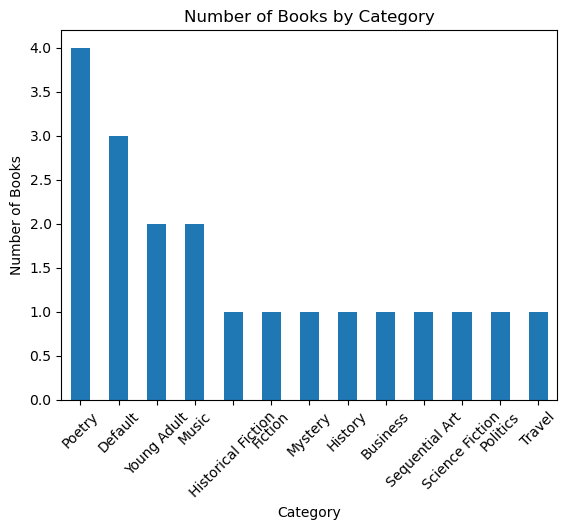

In [45]:
# Har category mein books ki count nikalna
category_count = df["category"].value_counts()

# Category-wise book count ka bar chart banana
category_count.plot(kind="bar")

# Chart ka title set karna
plt.title("Number of Books by Category")

# X-axis ka label
plt.xlabel("Category")

# Y-axis ka label
plt.ylabel("Number of Books")

# Labels ko readable banane ke liye rotate karna
plt.xticks(rotation=45)

# Chart ko properly display karna
plt.show()

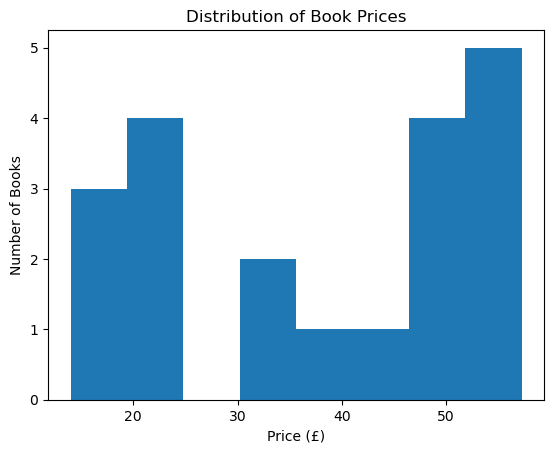

In [46]:
# Book prices ka histogram banana
plt.hist(df["price"], bins=8)

# Chart ka title
plt.title("Distribution of Book Prices")

# X-axis ka label
plt.xlabel("Price (£)")

# Y-axis ka label
plt.ylabel("Number of Books")

# Chart display karna
plt.show()

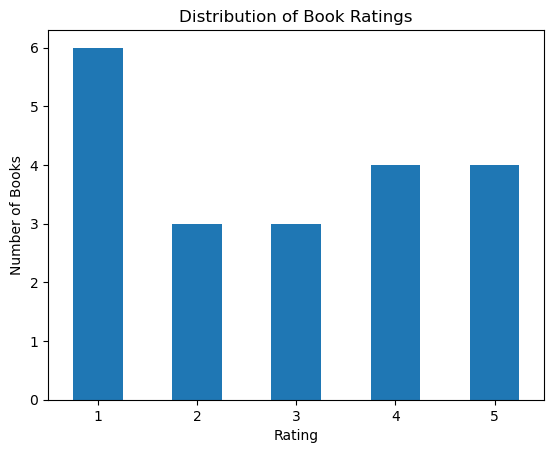

In [47]:
# Har rating ki book count nikalna
rating_count = df["rating"].value_counts().sort_index()

# Rating distribution ka bar chart banana
rating_count.plot(kind="bar")

# Chart ka title
plt.title("Distribution of Book Ratings")

# X-axis ka label
plt.xlabel("Rating")

# Y-axis ka label
plt.ylabel("Number of Books")

# X-axis labels ko horizontal rakhna
plt.xticks(rotation=0)

# Chart display karna
plt.show()

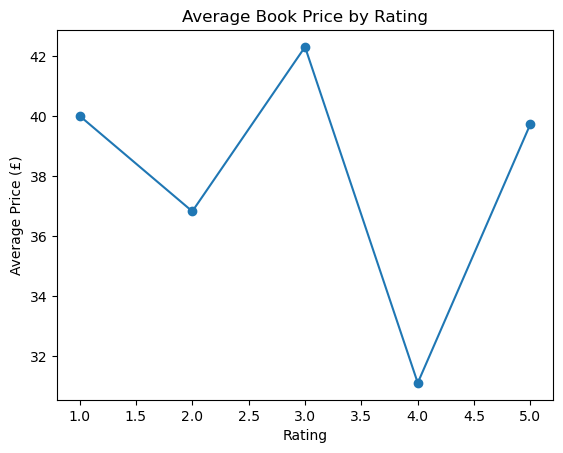

In [48]:
# Rating ke according average price calculate karna
price_by_rating = df.groupby("rating")["price"].mean()

# Result ko rating 1 se 5 ke order mein arrange karna
price_by_rating = price_by_rating.sort_index()

# Rating vs Average Price ka line chart banana
price_by_rating.plot(kind="line", marker="o")

# Chart ka title
plt.title("Average Book Price by Rating")

# X-axis ka label
plt.xlabel("Rating")

# Y-axis ka label
plt.ylabel("Average Price (£)")

# Chart display karna
plt.show()

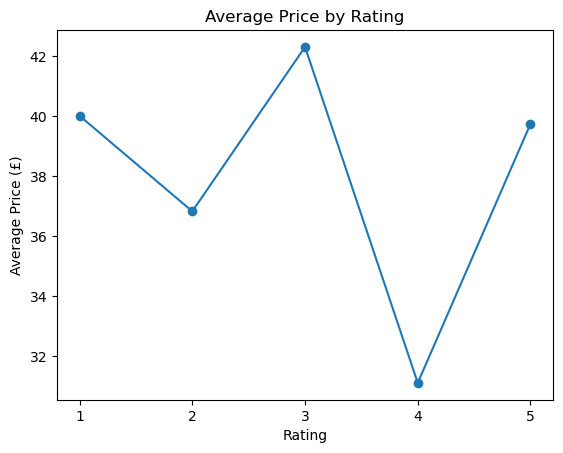

In [50]:
# Rating ke according average price ka line chart banana
price_by_rating.plot(kind="line", marker="o")

# Chart ka title
plt.title("Average Price by Rating")

# X-axis ka label
plt.xlabel("Rating")

# Y-axis ka label
plt.ylabel("Average Price (£)")

# X-axis par rating 1, 2, 3, 4, 5 dikhana
plt.xticks([1, 2, 3, 4, 5])

# Chart display karna
plt.show()

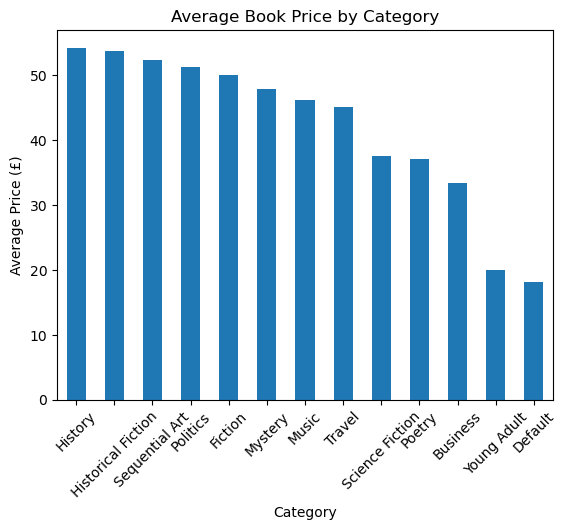

In [51]:
# Category-wise average price ka bar chart banana
category_avg_price.plot(kind="bar")

# Chart ka title
plt.title("Average Book Price by Category")

# X-axis ka label
plt.xlabel("Category")

# Y-axis ka label
plt.ylabel("Average Price (£)")

# Category names ko readable banane ke liye rotate karna
plt.xticks(rotation=45)

# Chart display karna
plt.show()

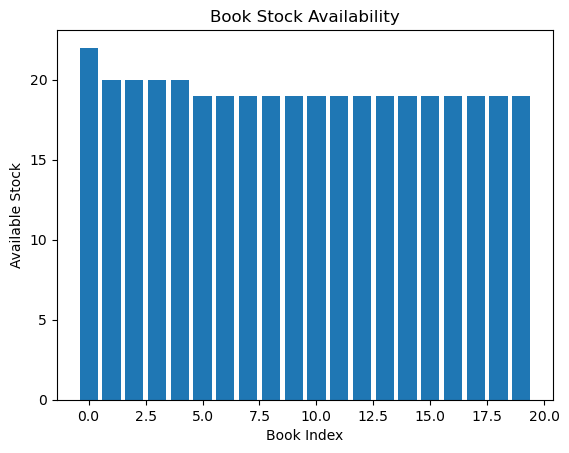

In [52]:
# Har book ke stock ka bar chart banana
plt.bar(range(len(df)), df["stock"])

# Chart ka title
plt.title("Book Stock Availability")

# X-axis ka label
plt.xlabel("Book Index")

# Y-axis ka label
plt.ylabel("Available Stock")

# Chart display karna
plt.show()

In [53]:
# Price ke basis par books ko highest se lowest sort karna
expensive_books = df.sort_values("price", ascending=False)

# Price ke basis par books ko lowest se highest sort karna
cheapest_books = df.sort_values("price", ascending=True)

# Top 5 expensive books display karna
print("Top 5 Most Expensive Books:")
print(expensive_books[["title", "price"]].head())

# Top 5 cheapest books display karna
print("\nTop 5 Cheapest Books:")
print(cheapest_books[["title", "price"]].head())

Top 5 Most Expensive Books:
                                                title  price
15  Our Band Could Be Your Life: Scenes from the A...  57.25
4               Sapiens: A Brief History of Humankind  54.23
1                                  Tipping the Velvet  53.74
13  Scott Pilgrim's Precious Little Life (Scott Pi...  52.29
9                                     The Black Maria  52.15

Top 5 Cheapest Books:
                                                title  price
10     Starving Hearts (Triangular Trade Trilogy, #1)  13.99
12                                        Set Me Free  17.46
7   The Coming Woman: A Novel Based on the Life of...  17.93
11                              Shakespeare's Sonnets  20.66
8   The Boys in the Boat: Nine Americans and Their...  22.60


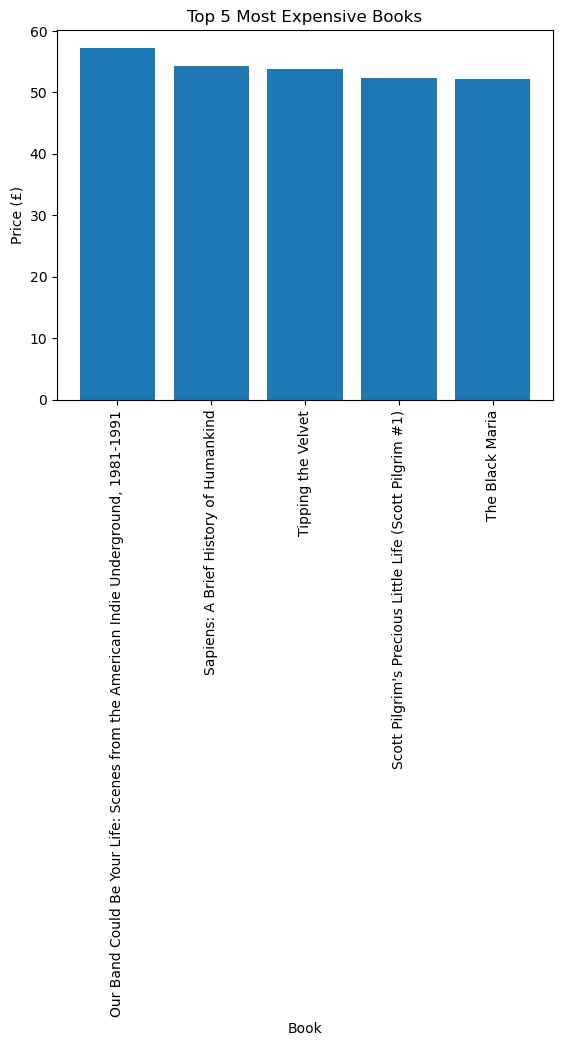

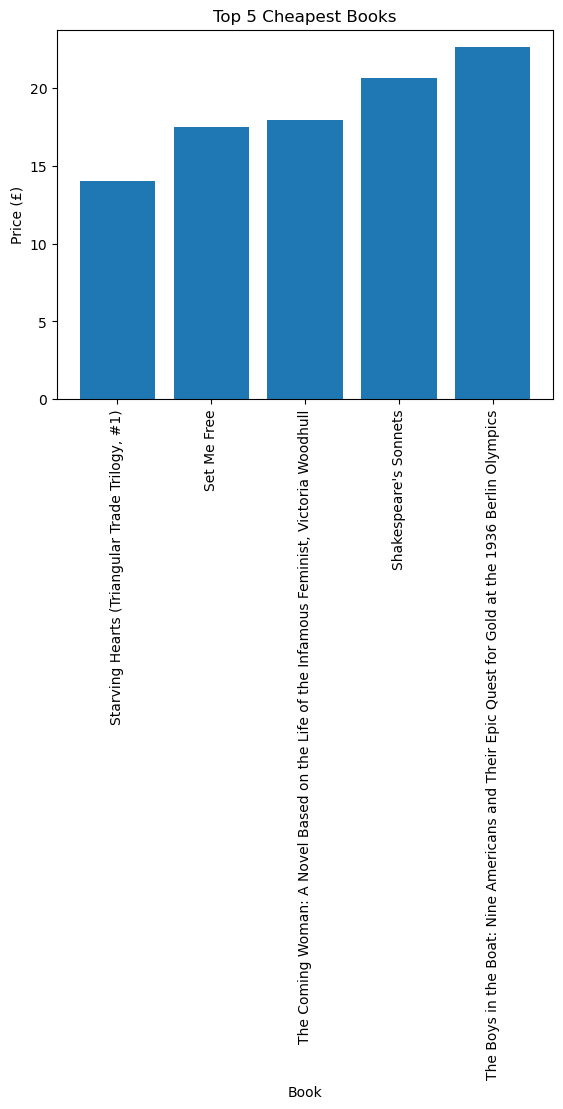

In [54]:
# Top 5 expensive books select karna
top_expensive = df.nlargest(5, "price")

# Top 5 cheapest books select karna
top_cheapest = df.nsmallest(5, "price")


# -------------------------------
# Top 5 Most Expensive Books
# -------------------------------

# Expensive books ka bar chart banana
plt.bar(top_expensive["title"], top_expensive["price"])

# Chart ka title
plt.title("Top 5 Most Expensive Books")

# X-axis ka label
plt.xlabel("Book")

# Y-axis ka label
plt.ylabel("Price (£)")

# Long book titles ko readable banane ke liye rotate karna
plt.xticks(rotation=90)

# Chart display karna
plt.show()


# -------------------------------
# Top 5 Cheapest Books
# -------------------------------

# Cheapest books ka bar chart banana
plt.bar(top_cheapest["title"], top_cheapest["price"])

# Chart ka title
plt.title("Top 5 Cheapest Books")

# X-axis ka label
plt.xlabel("Book")

# Y-axis ka label
plt.ylabel("Price (£)")

# Long book titles ko readable banane ke liye rotate karna
plt.xticks(rotation=90)

# Chart display karna
plt.show()

In [55]:
# Har category mein books ki count nikalna
category_count = df["category"].value_counts()

# Total books ki count
total_books = len(df)

# Har category ka percentage calculate karna
category_percentage = (category_count / total_books) * 100

# Category count aur percentage ko ek DataFrame mein combine karna
category_summary = pd.DataFrame({
    "Book Count": category_count,
    "Percentage": category_percentage.round(2)
})

# Result display karna
print(category_summary)

                    Book Count  Percentage
category                                  
Poetry                       4        20.0
Default                      3        15.0
Young Adult                  2        10.0
Music                        2        10.0
Historical Fiction           1         5.0
Fiction                      1         5.0
Mystery                      1         5.0
History                      1         5.0
Business                     1         5.0
Sequential Art               1         5.0
Science Fiction              1         5.0
Politics                     1         5.0
Travel                       1         5.0


In [56]:
# Har column mein missing values count karna
print("Missing Values:")
print(df.isnull().sum())

# Duplicate rows ki count check karna
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
title           0
price           0
rating          0
availability    0
category        0
upc             0
reviews         0
stock           0
dtype: int64

Duplicate Rows:
0


In [57]:
# Dataset mein total rows aur columns check karna
print("Dataset Shape:", df.shape)

# Dataset ke column names check karna
print("\nColumns:")
print(df.columns.tolist())

# Final dataset ki first 5 rows dekhna
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (20, 8)

Columns:
['title', 'price', 'rating', 'availability', 'category', 'upc', 'reviews', 'stock']

First 5 Rows:
                                   title  price  rating  \
0                   A Light in the Attic  51.77       3   
1                     Tipping the Velvet  53.74       1   
2                             Soumission  50.10       1   
3                          Sharp Objects  47.82       4   
4  Sapiens: A Brief History of Humankind  54.23       5   

              availability            category               upc  reviews  \
0  In stock (22 available)              Poetry  a897fe39b1053632        0   
1  In stock (20 available)  Historical Fiction  90fa61229261140a        0   
2  In stock (20 available)             Fiction  6957f44c3847a760        0   
3  In stock (20 available)             Mystery  e00eb4fd7b871a48        0   
4  In stock (20 available)             History  4165285e1663650f        0   

   stock  
0     22  
1     20  
2     20  
3     

In [58]:
# Final cleaned dataset ko CSV file mein save karna
df.to_csv("books_dataset.csv", index=False)

# Confirmation message display karna
print("Dataset successfully saved as books_dataset.csv")

Dataset successfully saved as books_dataset.csv


In [59]:

# Final Analysis Summary


# Sabse expensive book find karna
most_expensive = df.loc[df["price"].idxmax()]

# Sabse cheap book find karna
cheapest = df.loc[df["price"].idxmin()]

# Sabse high-rated book(s) find karna
highest_rated = df[df["rating"] == df["rating"].max()]

# Sabse zyada books wali category find karna
most_common_category = df["category"].value_counts().idxmax()

# Final results display karna
print("Most Expensive Book:")
print(most_expensive[["title", "price"]])

print("\nCheapest Book:")
print(cheapest[["title", "price"]])

print("\nHighest Rating:")
print(df["rating"].max())

print("\nMost Common Category:")
print(most_common_category)

print("\nTotal Books:")
print(len(df))

Most Expensive Book:
title    Our Band Could Be Your Life: Scenes from the A...
price                                                57.25
Name: 15, dtype: object

Cheapest Book:
title    Starving Hearts (Triangular Trade Trilogy, #1)
price                                             13.99
Name: 10, dtype: object

Highest Rating:
5

Most Common Category:
Poetry

Total Books:
20


In [60]:

# Final Project Findings


# Average price calculate karna
average_price = df["price"].mean()

# Average rating calculate karna
average_rating = df["rating"].mean()

# Total stock calculate karna
total_stock = df["stock"].sum()

# Most common category find karna
most_common_category = df["category"].value_counts().idxmax()

# Most expensive book find karna
most_expensive = df.loc[df["price"].idxmax(), "title"]

# Cheapest book find karna
cheapest = df.loc[df["price"].idxmin(), "title"]

# Final findings display karna
print("===== FINAL FINDINGS =====")

print(f"Total Books Scraped: {len(df)}")
print(f"Average Book Price: £{average_price:.2f}")
print(f"Average Rating: {average_rating:.2f}")
print(f"Total Available Stock: {total_stock}")
print(f"Most Common Category: {most_common_category}")
print(f"Most Expensive Book: {most_expensive}")
print(f"Cheapest Book: {cheapest}")

===== FINAL FINDINGS =====
Total Books Scraped: 20
Average Book Price: £38.05
Average Rating: 2.85
Total Available Stock: 387
Most Common Category: Poetry
Most Expensive Book: Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Cheapest Book: Starving Hearts (Triangular Trade Trilogy, #1)


In [61]:
# -------------------------------
# Saved CSV file ko verify karna
# -------------------------------

# CSV file ko Pandas DataFrame mein read karna
df_check = pd.read_csv("books_dataset.csv")

# CSV ka size check karna
print("CSV Shape:", df_check.shape)

# CSV ke columns check karna
print("\nCSV Columns:")
print(df_check.columns.tolist())

# CSV ki first 5 rows display karna
print("\nFirst 5 Rows:")
print(df_check.head())

CSV Shape: (20, 8)

CSV Columns:
['title', 'price', 'rating', 'availability', 'category', 'upc', 'reviews', 'stock']

First 5 Rows:
                                   title  price  rating  \
0                   A Light in the Attic  51.77       3   
1                     Tipping the Velvet  53.74       1   
2                             Soumission  50.10       1   
3                          Sharp Objects  47.82       4   
4  Sapiens: A Brief History of Humankind  54.23       5   

              availability            category               upc  reviews  \
0  In stock (22 available)              Poetry  a897fe39b1053632        0   
1  In stock (20 available)  Historical Fiction  90fa61229261140a        0   
2  In stock (20 available)             Fiction  6957f44c3847a760        0   
3  In stock (20 available)             Mystery  e00eb4fd7b871a48        0   
4  In stock (20 available)             History  4165285e1663650f        0   

   stock  
0     22  
1     20  
2     20  
3     

In [62]:
# -------------------------------
# Final Project Overview
# -------------------------------

# Total scraped book URLs
print("Total Book URLs:", len(full_links))

# Total books in DataFrame
print("Total Books in Dataset:", len(df))

# Total columns
print("Total Columns:", len(df.columns))

# Column names
print("Columns:", df.columns.tolist())

# CSV file ka naam
print("CSV File: books_dataset.csv")

Total Book URLs: 20
Total Books in Dataset: 20
Total Columns: 8
Columns: ['title', 'price', 'rating', 'availability', 'category', 'upc', 'reviews', 'stock']
CSV File: books_dataset.csv


In [63]:
# -------------------------------
# Final Clean Dataset
# -------------------------------

# Cleaned dataset ki copy banana
final_df = df.copy()

# Final dataset ko CSV file mein save karna
final_df.to_csv("books_dataset_final.csv", index=False)

# Confirmation message
print("Final dataset saved successfully!")
print("File: books_dataset_final.csv")

Final dataset saved successfully!
File: books_dataset_final.csv


In [64]:
# -------------------------------
# FINAL PROJECT STATUS
# -------------------------------

print("===== WEB SCRAPING PROJECT STATUS =====")

# Scraped books ki total count
print("1. Books Scraped:", len(df))

# Dataset ke total columns
print("2. Dataset Columns:", len(df.columns))

# Missing values check
print("3. Missing Values:", df.isnull().sum().sum())

# Duplicate rows check
print("4. Duplicate Rows:", df.duplicated().sum())

# Final CSV file
print("5. Final CSV: books_dataset_final.csv")

print("\n===== PROJECT COMPLETE =====")

===== WEB SCRAPING PROJECT STATUS =====
1. Books Scraped: 20
2. Dataset Columns: 8
3. Missing Values: 0
4. Duplicate Rows: 0
5. Final CSV: books_dataset_final.csv

===== PROJECT COMPLETE =====
